In [15]:
# Import necessary libraries
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'svg'

print("Libraries imported successfully!")

# Connect to the SQLite database
conn = sqlite3.connect("inventory.db")

# Create a cursor object to interact with the database
cursor = conn.cursor()

# Function to run a SQL query and return the results as a DataFrame
def run_query_to_df(cursor, query):
    cursor.execute(query)
    rows = cursor.fetchall()
    
    # Get column names from cursor
    columns = []
    for col in cursor.description:
        columns.append(col[0])

    # Convert to DataFrame
    df = pd.DataFrame(rows, columns = columns)

    return df

Libraries imported successfully!


In [16]:
query = """
SELECT
    SUM(p.product_price * oi.quantity) AS total_revenue,
    SUM(CASE WHEN s.late_delivery_risk = 1
        THEN p.product_price * oi.quantity ELSE 0 END) AS revenue_at_risk
FROM orders o
JOIN order_items oi ON o.id = oi.order_id
JOIN shipping s    ON o.id = s.order_id
JOIN products p    ON oi.product_id = p.id
"""

# Call the function to run the query and display results
result = run_query_to_df(cursor, query)
result['pct_at_risk'] = round(result['revenue_at_risk'] / result['total_revenue'] * 100, 2)
result

,total_revenue,revenue_at_risk,pct_at_risk
0,3.678473e+07,2.012640e+07,54.71


In [17]:
query = """
SELECT
    o.order_date,
    p.product_price * oi.quantity AS order_revenue,
    s.late_delivery_risk
FROM orders o
JOIN order_items oi ON o.id = oi.order_id
JOIN shipping s    ON o.id = s.order_id
JOIN products p    ON oi.product_id = p.id
"""

data = run_query_to_df(cursor, query)
data['order_date'] = pd.to_datetime(data['order_date'])
data['order_month'] = data['order_date'].dt.to_period('M')
data['at_risk_revenue'] = data['order_revenue'] * data['late_delivery_risk']

monthly = data.groupby('order_month').agg(
    total_revenue=('order_revenue', 'sum'),
    revenue_at_risk=('at_risk_revenue', 'sum')
).reset_index()

monthly['month_index'] = range(len(monthly))
monthly.head(10)

,order_month,total_revenue,revenue_at_risk,month_index
0,2015-01,1.051590e+06,570920.860118,0
1,2015-02,9.270099e+05,508672.909679,1
2,2015-03,1.051254e+06,571798.370231,2
3,2015-04,1.014463e+06,547556.390495,3
4,2015-05,1.050478e+06,580294.990281,4
5,2015-06,1.024006e+06,554935.860256,5
6,2015-07,1.038081e+06,578889.800716,6
7,2015-08,1.029495e+06,579159.510933,7
8,2015-09,1.018339e+06,577902.390885,8
9,2015-10,1.049154e+06,571324.380470,9


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

late_rate = result.iloc[0]['pct_at_risk'] / 100
forecast_months = 12

X = monthly[['month_index']]
y = monthly['total_revenue']

model = LinearRegression()
model.fit(X, y)

future_X = np.arange(len(monthly), len(monthly) + forecast_months).reshape(-1, 1)
future_revenue = model.predict(future_X)
future_at_risk = future_revenue * late_rate

print(f"Late delivery rate: {late_rate * 100:.1f}%")
print(f"R²: {r2_score(y, model.predict(X)):.2f}")
print(f"Projected revenue at risk (next {forecast_months} months): ${future_at_risk.sum():,.0f}")

Late delivery rate: 54.7%
R²: 0.12
Projected revenue at risk (next 12 months): $5,692,749


/usr/local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


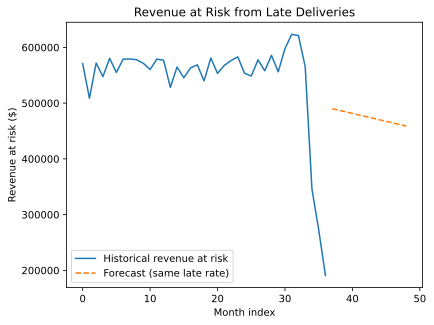

In [19]:
plt.plot(monthly['month_index'], monthly['revenue_at_risk'], label='Historical revenue at risk')
plt.plot(future_X, future_at_risk, '--', label='Forecast (same late rate)')
plt.title('Revenue at Risk from Late Deliveries')
plt.xlabel('Month index')
plt.ylabel('Revenue at risk ($)')
plt.legend()
plt.show()